In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from __loader__ import LINCSpaths, CCLEpaths, Loader
from __analysis__ import annotate_drug_info, annotate_cell_info
INPUT    = Path('/home/gdelrot/pathway_perturb/data')
OUTPUT   = Path('/home/gdelrot/pathway_perturb/outputs/out_exploration_2')
MNT_L1000 = Path('/mnt/cbib/l1000/data/')
lincs_sigcom = LINCSpaths(
        gctx=str(MNT_L1000 / 'cp_coeff_mat.gctx'),
        pathway=str(INPUT / 'gsea_l1000.parquet'),
        sig_info=str(MNT_L1000 / 'siginfo_beta.txt'),
        gene_info=str(MNT_L1000 / 'geneinfo_beta.txt.gz'),
        cell_info=str(MNT_L1000 / 'cellinfo_beta.txt.gz'),
        compound_info=str(MNT_L1000 / 'compoundinfo_beta.txt.gz'),
        inst_info=str(MNT_L1000 / 'instinfo_beta.txt.gz'),
    )
ccle_data = CCLEpaths(
    transcriptomics=str(INPUT / 'CCLE_RNAseq_genes_rpkm_20180929.gct'),
    metabolomics=str(INPUT / 'CCLE_metabolomics_20190502.csv'),
    cell_annotations=str(INPUT / 'Cell_lines_annotations_20181226.txt'),
    metabo_mapping=str(INPUT / 'metabo_mapping.csv'),
    depmap_annotation=str(INPUT / 'Depmap_annotation.csv'),
)
loader = Loader(lincs_paths=lincs_sigcom, ccle_paths=ccle_data)
loader.load_l1000_metadata()
loader.load_l1000_pathway_scores()
my_perts = loader.l1000_pathway_data.index

/home/gdelrot/pathway_perturb/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading metadata nested in gctx file...
chd                                  cell_line  inchi_key  lincs_id  \
cid                                                                   
ABY001_A375_XH:BRD-K66175015:10:24         NaN        NaN       NaN   
ABY001_A375_XH:BRD-K70401845:10:24         NaN        NaN       NaN   
ABY001_A375_XH:BRD-K85606544:10:24         NaN        NaN       NaN   
ABY001_A375_XH:BRD-K19687926:10:24         NaN        NaN       NaN   
ABY001_A375_XH:BRD-K66175015:2.5:24        NaN        NaN       NaN   

chd                                  pert_aliases  pert_dose  pert_id  \
cid                                                                     
ABY001_A375_XH:BRD-K66175015:10:24            NaN        NaN      NaN   
ABY001_A375_XH:BRD-K70401845:10:24            NaN        NaN      NaN   
ABY001_A375_XH:BRD-K85606544:10:24            NaN        NaN      NaN   
ABY001_A375_XH:BRD-K19687926:10:24            NaN        NaN      NaN   
ABY001_A375_XH:BRD-K6617

Initial sig info size: (1201944, 37)
After sig info size: (718157, 37)
Initial compound info size: (119143, 8)
UNique compound info size: (119143, 8)


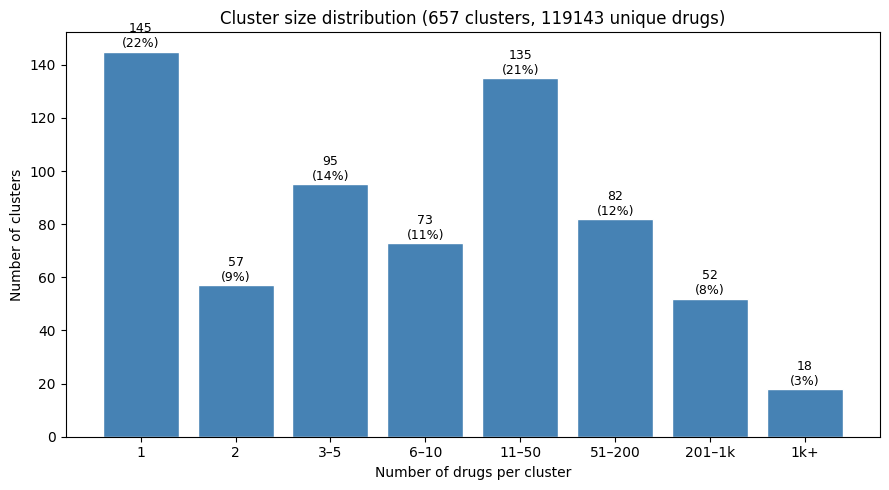

In [23]:
import numpy as np
pd.set_option('display.max_rows',None)
# Statistics on all the different drugs
compound_info = loader.compound_info
sig_info = loader.sig_info

# Keep perturbations in the l1000 pathway dataset
print(f'Initial sig info size: {sig_info.shape}')
sig_info = sig_info[sig_info['sig_id'].isin(my_perts)]
print(f'After sig info size: {sig_info.shape}')

# Drug info
print(f'Initial compound info size: {compound_info.shape}')
#compound_info = compound_info.drop_duplicates(subset='cmap_name')
print(f'UNique compound info size: {compound_info.shape}')

moa_grouped = compound_info.groupby('moa')['cmap_name'].size()

# --- Adapt bins to YOUR data range ---
bin_edges = [0.5, 1.5, 2.5, 5.5, 10.5, 50.5, 200.5, 1000.5, moa_grouped.max() + 1]
bin_labels = ['1', '2', '3–5', '6–10', '11–50', '51–200', '201–1k', '1k+']

counts, _ = np.histogram(moa_grouped, bins=bin_edges)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(range(len(counts)), counts, color='steelblue', edgecolor='white')
ax.set_xticks(range(len(counts)))
ax.set_xticklabels(bin_labels)
ax.set_xlabel('Number of drugs per cluster')
ax.set_ylabel('Number of clusters')
ax.set_title(f'Cluster size distribution ({len(moa_grouped)} clusters, {compound_info.shape[0]} unique drugs)')

total = counts.sum()
for bar, count in zip(bars, counts):
    if count > 0:
        pct = count / total * 100
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                f'{count}\n({pct:.0f}%)', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

Unique drug with a smiles: 27843
            n_drugs  n_sigs  n_cell_lines
cluster_id                               
2663.0         2966   21501            61
2666.0         2559    6999            16
2672.0         1583    5867            16
2658.0         1121    4234            16
2661.0          994    3213            18
2660.0          953    3274            15
2659.0          933    3946            14
2695.0          666    6676            17
2665.0          650    5685            17
2558.0          579    2560            14
2686.0          432    1629            14
2662.0          391    3618            19
2685.0          364    1126            14
2645.0          334    2113            12
2664.0          329    1808            14
2678.0          322    1264            14
2690.0          316    1189            14
2692.0          286     893            14
2646.0          283    1679            11
2652.0          259    1133            14
2549.0          226    1240            13
2

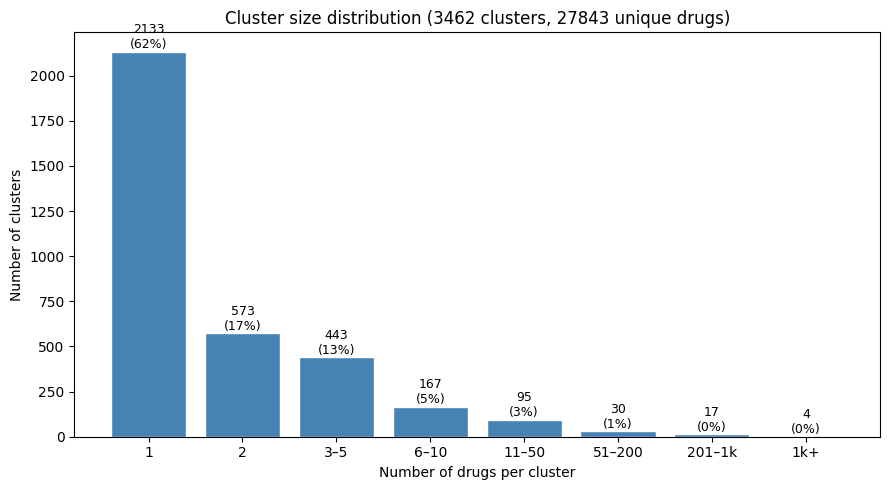

In [22]:
import numpy as np
compound_info = loader.compound_info
sig_info = loader.sig_info
compound_info = compound_info.drop_duplicates(subset = 'cmap_name')
compound_info = compound_info.dropna(subset= 'canonical_smiles')
print(f'Unique drug with a smiles: {compound_info.shape[0]}')

moa_grouped = compound_info.groupby('cluster_id')['cmap_name'].size()
compound_info['cluster_id'] = compound_info['cluster_id'].astype(str)
sig_moa = sig_info.merge(compound_info[['cmap_name','cluster_id']], on='cmap_name', how='left')
sig_per_moa = sig_moa.groupby('cluster_id')['sig_id'].count().sort_values(ascending=False)
cell_per_moa = sig_moa.groupby('cluster_id')['cell_iname'].nunique().sort_values(ascending=False)
summary = pd.DataFrame({
    'n_drugs': moa_grouped,
    'n_sigs': sig_per_moa,
    'n_cell_lines': cell_per_moa
}).sort_values('n_drugs', ascending=False).head(30)
print(summary)
# --- Adapt bins to YOUR data range ---
bin_edges = [0.5, 1.5, 2.5, 5.5, 10.5, 50.5, 200.5, 1000.5, moa_grouped.max() + 1]
bin_labels = ['1', '2', '3–5', '6–10', '11–50', '51–200', '201–1k', '1k+']

counts, _ = np.histogram(moa_grouped, bins=bin_edges)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(range(len(counts)), counts, color='steelblue', edgecolor='white')
ax.set_xticks(range(len(counts)))
ax.set_xticklabels(bin_labels)
ax.set_xlabel('Number of drugs per cluster')
ax.set_ylabel('Number of clusters')
ax.set_title(f'Cluster size distribution ({len(moa_grouped)} clusters, {compound_info.shape[0]} unique drugs)')

total = counts.sum()
for bar, count in zip(bars, counts):
    if count > 0:
        pct = count / total * 100
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                f'{count}\n({pct:.0f}%)', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

(27843, 8)
Unique drug with a moa: 2555
                                         n_drugs  n_sigs  n_cell_lines
moa                                                                   
Dopamine receptor antagonist                  64    8267           172
Cyclooxygenase inhibitor                      62    7616           119
Adrenergic receptor antagonist                56    4915            93
Histamine receptor antagonist                 54    4848            73
Serotonin receptor antagonist                 50    3511            91
Acetylcholine receptor antagonist             48    3278            33
Adrenergic receptor agonist                   44    4574           170
Serotonin receptor agonist                    44    3283            55
Glutamate receptor antagonist                 40    2785            54
Phosphodiesterase inhibitor                   38    7705           174
Glucocorticoid receptor agonist               34    3262            96
EGFR inhibitor                       

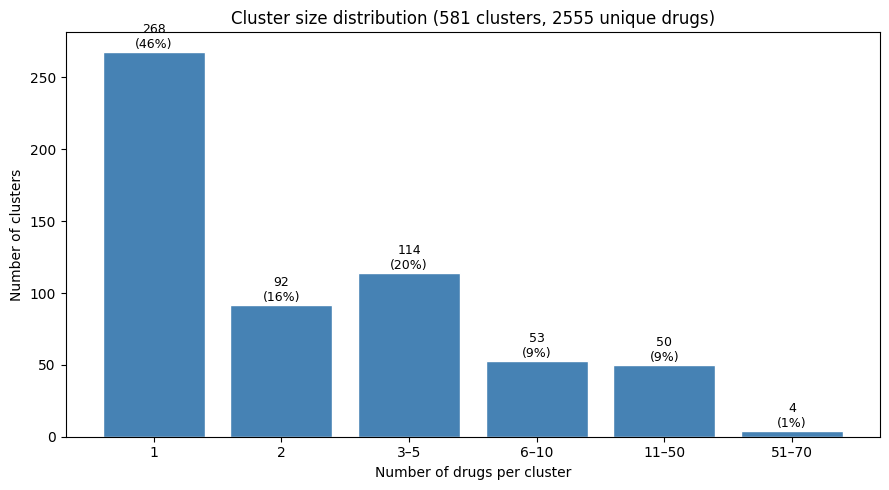

In [25]:
compound_info = loader.compound_info
sig_info = loader.sig_info
compound_info = compound_info.drop_duplicates(subset = 'cmap_name')
print(compound_info.shape)
moa_grouped = compound_info.groupby('moa')['cmap_name'].size()
compound_info = compound_info.dropna(subset = 'moa')
print(f'Unique drug with a moa: {compound_info.shape[0]}')
sig_moa = sig_info.merge(compound_info[['cmap_name','moa']], on='cmap_name', how='left')
sig_per_moa = sig_moa.groupby('moa')['sig_id'].count().sort_values(ascending=False)
cell_per_moa = sig_moa.groupby('moa')['cell_iname'].nunique().sort_values(ascending=False)
summary = pd.DataFrame({
    'n_drugs': moa_grouped,
    'n_sigs': sig_per_moa,
    'n_cell_lines': cell_per_moa
}).sort_values('n_drugs', ascending=False).head(30)
print(summary)
# --- Adapt bins to YOUR data range ---
bin_edges = [0.5, 1.5, 2.5, 5.5, 10.5, 50.5, moa_grouped.max() + 1]
bin_labels = ['1', '2', '3–5', '6–10', '11–50', '51–70']

counts, _ = np.histogram(moa_grouped, bins=bin_edges)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(range(len(counts)), counts, color='steelblue', edgecolor='white')
ax.set_xticks(range(len(counts)))
ax.set_xticklabels(bin_labels)
ax.set_xlabel('Number of drugs per cluster')
ax.set_ylabel('Number of clusters')
ax.set_title(f'Cluster size distribution ({len(moa_grouped)} clusters, {compound_info.shape[0]} unique drugs)')

total = counts.sum()
for bar, count in zip(bars, counts):
    if count > 0:
        pct = count / total * 100
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                f'{count}\n({pct:.0f}%)', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()